In [14]:
# -*- coding: utf-8 -*-
"""
Vibrations and Stuff
Introduction to State Space formulation
Process equation and observation equation
@author: LC
"""
import numpy as np
from scipy.linalg import expm, inv
import matplotlib.pyplot as plt


In [15]:
M = np.array([[1, 0],
              [0, 1]])


K = np.array([[2500, -1500],
              [-1500, 1500]])


C = np.array([[4.64, -1.87],
              [-1.87, 3.39]])

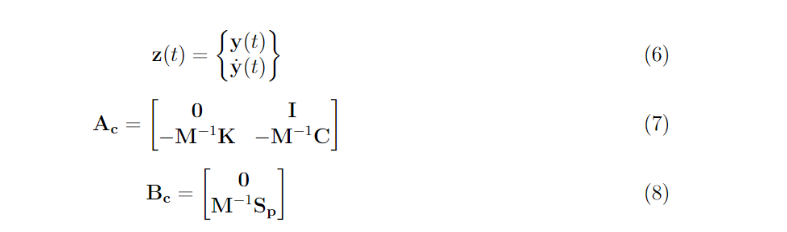

In [16]:
dt = 0.01
t_end = 10

# load influence/distribution matrix
Sp = np.zeros([2,1])
Sp[1,0] = 1


n = len(M)
nLoads = Sp.shape[1]

# System matrix - continuous time
Ac = np.zeros((2*n,2*n))
Ac[:n,:n] = np.zeros((n,n))
Ac[:n,n:2*n] = np.identity(n)
Ac[n:2*n,:n] = - np.linalg.inv(M) @ K
Ac[n:2*n,n:2*n] = - np.linalg.inv(M) @ C


# Input matrix - continuous time 
Bc  = np.zeros((2*n,nLoads))
Bc[n:2*n,:] = np.linalg.inv(M) @ Sp



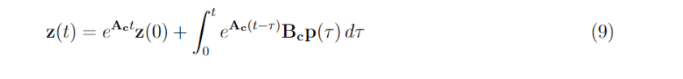

In [ ]:
# State transition matrix - discrete time
A = expm(Ac*dt)

# Input matrix - discrete time - Zero-order hold
B = np.matmul(A-np.identity(2*n),np.linalg.inv(Ac)) @ Bc

nsteps = int(t_end/dt)
time_array = np.arange(nsteps)*dt

#%% Free vibration


# initialize state vector
z_vec = np.zeros([2*n,nsteps])

# initial displacement vector
y0 = np.array([0,1])
#initial velocity vector
ydot0 = np.array([0,0])

#set initial conditions
z_vec[:,0] = np.concatenate((y0,ydot0))

#compute response recursively
for k in range(0,nsteps-1):
    z_vec[:,k+1] = A@z_vec[:,k]

In [ ]:
#%% Forced vibration
# force vector
p = np.zeros((1,nsteps))
p += 300 * np.sin(10*time_array)

# initialize state vector
z_vec = np.zeros([2*n,nsteps])

# initial displacement vector
y0 = np.array([0,0])
#initial velocity vector
ydot0 = np.array([0,0])

#set initial conditions
z_vec[:,0] = np.concatenate((y0,ydot0))

for k in range(0,nsteps-1):
    z_vec[:,k+1] = A@z_vec[:,k] + B@p[:,k]

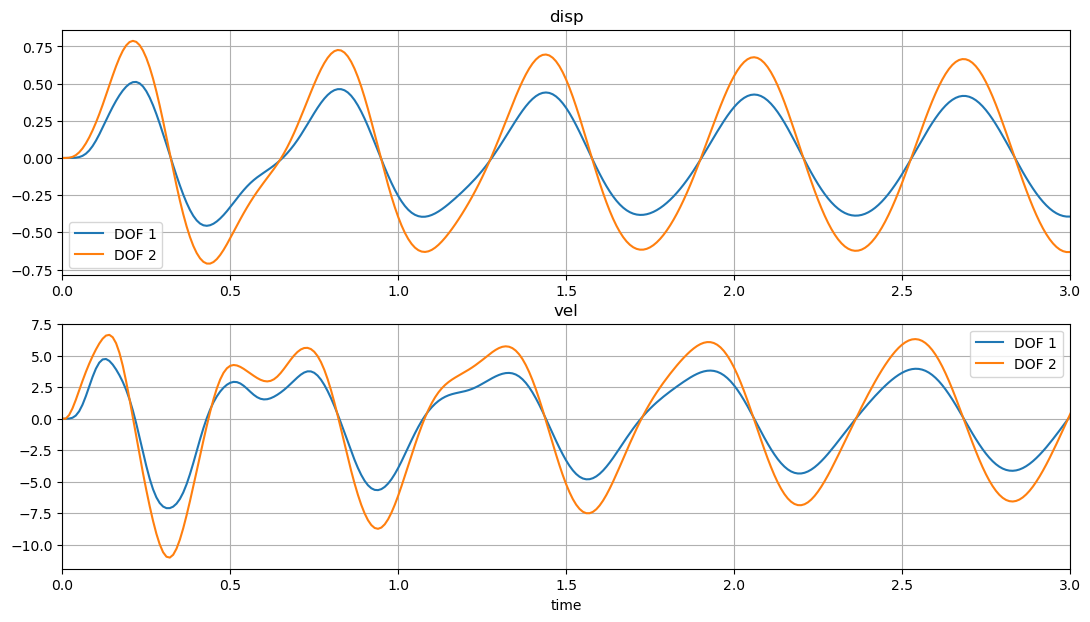

In [ ]:
# plot
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(13,7))

ax1.set_title("disp")
ax2.set_title("vel")

ax1.plot(time_array,z_vec[0,:],label="DOF 1")
ax1.plot(time_array,z_vec[1,:],label="DOF 2")

ax2.plot(time_array,z_vec[2,:],label="DOF 1")
ax2.plot(time_array,z_vec[3,:],label="DOF 2")

for ax in (ax1,ax2):
    ax.legend()
    ax.grid()

ax1.set_xlim([0,3])
ax2.set_xlim([0,3])
ax2.set_xlabel("time")
plt.show()

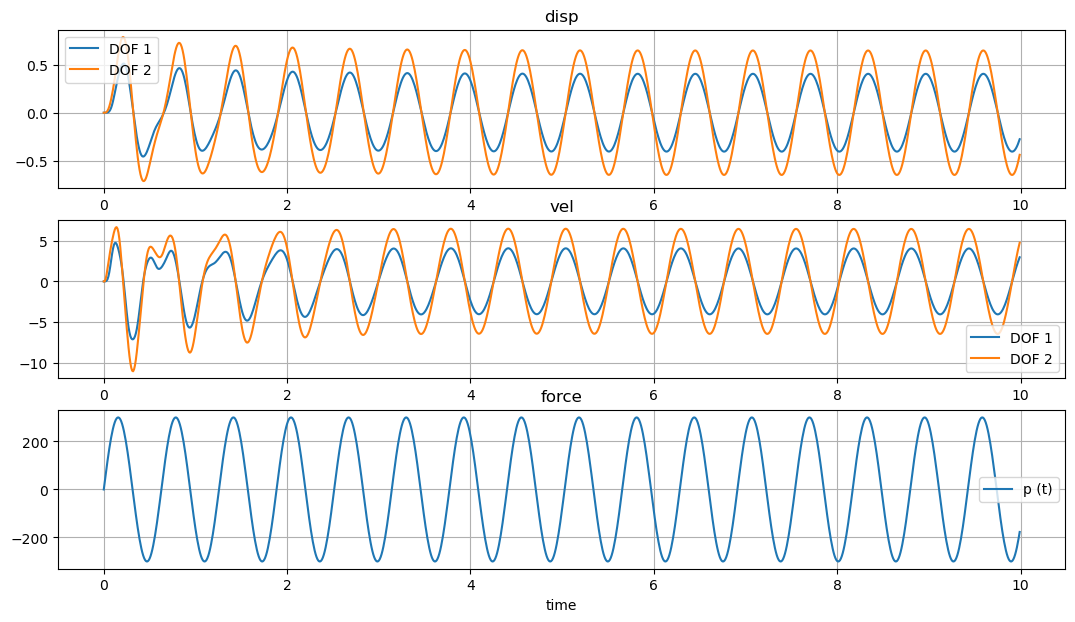

In [20]:
# plot

fig, (ax1,ax2, ax3) = plt.subplots(3,1,figsize=(13,7))

ax1.set_title("disp")
ax2.set_title("vel")
ax3.set_title("force")

ax1.plot(time_array,z_vec[0,:],label="DOF 1")
ax1.plot(time_array,z_vec[1,:],label="DOF 2")

ax2.plot(time_array,z_vec[2,:],label="DOF 1")
ax2.plot(time_array,z_vec[3,:],label="DOF 2")

ax3.plot(time_array,p[0,:],label="p (t)")

for ax in (ax1,ax2,ax3):
    ax.legend()
    ax.grid()

# ax1.set_ylim([-1,1])
# ax2.set_ylim([-32,22])
ax3.set_xlabel("time")
plt.show()

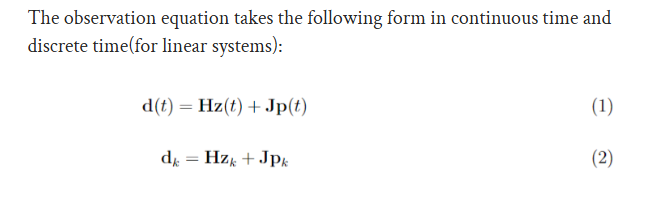

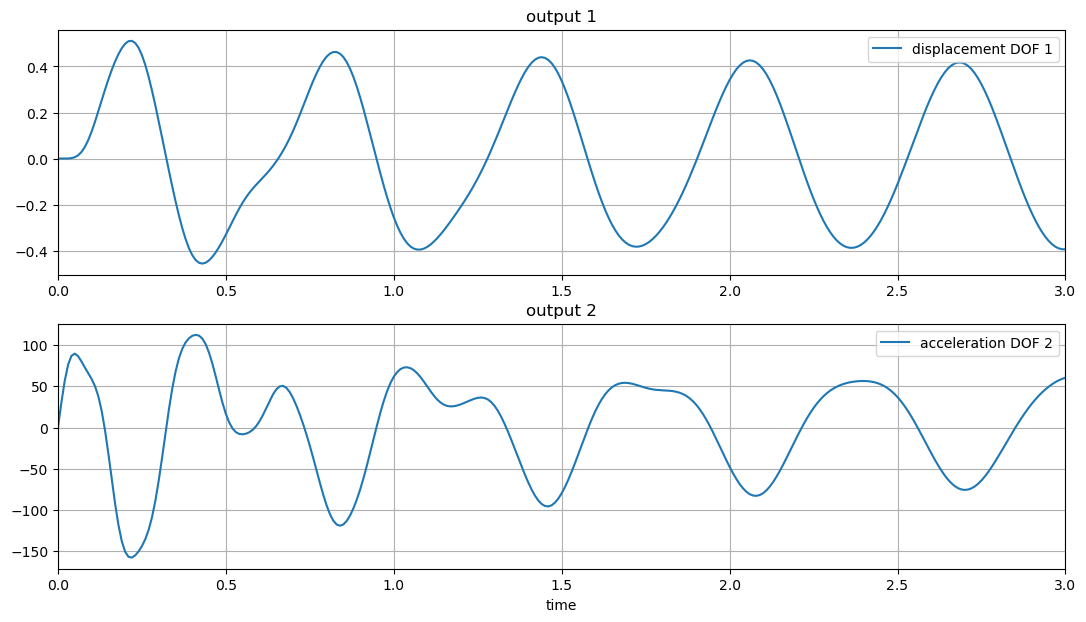

In [ ]:
#%% observation equation with output displacement of DOF1 and acceleration of DOF2


#output selection matrices for displacements, velocities and accelerations
Sd = np.identity(n)[[0]] # DOF 1
Sv = np.identity(n)[[]]  # none
Sa = np.identity(n)[[1]] # DOF 2

#output matrix
H = np.vstack((
                np.hstack((Sd,                np.zeros_like(Sd)  )),
                np.hstack((np.zeros_like(Sv), Sv                 )),
                np.hstack((-Sa@inv(M)@K,      -Sa@inv(M)@C       ))
                ))

#direct feedthrough matrix
J = np.vstack((
                np.zeros([len(Sd),nLoads]),
                np.zeros([len(Sv),nLoads]),
                Sa@inv(M)@Sp
                ))

# initialize state vector
z_vec = np.zeros([2*n,nsteps])

# initial displacement vector
y0 = np.array([0,0])
#initial velocity vector
ydot0 = np.array([0,0])

#set initial conditions
z_vec[:,0] = np.concatenate((y0,ydot0))


# initialize output vector
d = np.zeros([len(Sd)+len(Sv)+len(Sa),nsteps])

#initial output
d[:,0] = H@z_vec[:,0] + J@p[:,0]

#compute response recursively
for k in range(0,nsteps-1):
    z_vec[:,k+1] = A@z_vec[:,k] + B@p[:,k]
    d[:,k+1] = H@z_vec[:,k+1] + J@p[:,k+1]

# plot
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(13,7))

ax1.set_title("output 1")
ax2.set_title("output 2")

ax1.plot(time_array,d[0,:],label="displacement DOF 1")

ax2.plot(time_array,d[1,:],label="acceleration DOF 2")

for ax in (ax1,ax2):
    ax.legend()
    ax.grid()

ax1.set_xlim([0,3])
ax2.set_xlim([0,3])
ax2.set_xlabel("time")
plt.show()